# OASIS Alzheimer's Classification — SMOTE Experiment

**Goal:** Evaluate the effect of **SMOTE** (Synthetic Minority Over-sampling Technique) on the **top 3 best-performing models** identified in `OASIS_Baseline_Models.ipynb` (ranked by AUROC): **Random Forest, XGBoost, and the Hybrid Ensemble**.

This notebook reuses the exact same preprocessing pipeline and train/test split as the baseline notebook. SMOTE is applied **only to the training set** — the test set remains untouched and identical to the baseline, so results are directly comparable.

No new models or algorithms are introduced, no explainability analysis is performed, and no models outside the top 3 are retrained.

In [1]:
import sys
!{sys.executable} -m pip install catboost imbalanced-learn

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42

## 1. Load and Prepare Data

Identical to the baseline notebook: same CDR → Group labeling, same median imputation, same feature set (`CDR` excluded to avoid label leakage).

In [3]:
DATA_PATH = "oasis_cross-sectional.csv"  # update path if needed

df = pd.read_csv(DATA_PATH)

def cdr_to_group(cdr):
    if pd.isna(cdr):
        return "Unknown"
    elif cdr == 0:
        return "Nondemented"
    else:
        return "Demented"

df["Group"] = df["CDR"].apply(cdr_to_group)
df = df[df["Group"] != "Unknown"].reset_index(drop=True)  # drop subjects with no diagnosis

# Impute the few legitimately missing clinical fields (median)
for col in ["Educ", "SES", "MMSE"]:
    df[col] = df[col].fillna(df[col].median())

# Encode
df["Gender"] = df["M/F"].map({"M": 0, "F": 1})
df["Target"] = df["Group"].map({"Nondemented": 0, "Demented": 1})

# Feature set: biomarkers/demographics only -- CDR is excluded (see leakage note above)
FEATURES = ["Age", "Gender", "Educ", "SES", "MMSE", "eTIV", "nWBV", "ASF"]

X = df[FEATURES]
y = df["Target"]

print(f"Dataset shape after cleaning: {df.shape}")
print(y.value_counts())
df.head()

Dataset shape after cleaning: (235, 15)
Target
0    135
1    100
Name: count, dtype: int64


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,Group,Gender,Target
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN,Nondemented,1,0
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN,Nondemented,1,0
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN,Demented,1,1
3,OAS1_0010_MR1,M,R,74,5.0,2.0,30.0,0.0,1636,0.689,1.073,NaN,Nondemented,0,0
4,OAS1_0011_MR1,F,R,52,3.0,2.0,30.0,0.0,1321,0.827,1.329,NaN,Nondemented,1,0


## 2. Train/Test Split

Same 80/20 stratified split, same `RANDOM_STATE`, same scaler fit on the training set only — identical to the baseline notebook so the held-out test set is byte-for-byte the same.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=FEATURES, index=X_test.index)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Train class balance:")
print(y_train.value_counts())

Train: (188, 8), Test: (47, 8)
Train class balance:
Target
0    108
1     80
Name: count, dtype: int64


## 3. Apply SMOTE to the Training Set Only

SMOTE is fit and applied exclusively to `X_train` / `y_train`. `X_test` / `y_test` are never touched by SMOTE, so the test set used for evaluation is identical to the baseline notebook's test set.

In [5]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE -- Train: {X_train.shape}, class balance:\n{y_train.value_counts()}\n")
print(f"After SMOTE  -- Train: {X_train_smote.shape}, class balance:\n{pd.Series(y_train_smote).value_counts()}")

Before SMOTE -- Train: (188, 8), class balance:
Target
0    108
1     80
Name: count, dtype: int64

After SMOTE  -- Train: (216, 8), class balance:
Target
0    108
1    108
Name: count, dtype: int64


## 4. Baseline Results for the Top 3 Models

These are the reference numbers from `OASIS_Baseline_Models.ipynb` for the top 3 models by AUROC: **Random Forest, XGBoost, Hybrid Ensemble**. They are hard-coded here from the completed baseline run so this notebook does not need to retrain the full 11-model panel — only the top 3 are retrained below, with SMOTE.

In [6]:
# Baseline metrics (top 3 models by AUROC), taken from OASIS_Baseline_Models.ipynb, Table 1A
baseline_results = {
    "Random Forest":   {"Accuracy": 0.830, "F1": 0.778, "MCC": 0.653, "AUROC": 0.942},
    "XGBoost":         {"Accuracy": 0.851, "F1": 0.811, "MCC": 0.696, "AUROC": 0.941},
    "Hybrid Ensemble": {"Accuracy": 0.830, "F1": 0.778, "MCC": 0.653, "AUROC": 0.933},
}
TOP3 = list(baseline_results.keys())
print("Top 3 baseline models (by AUROC):", TOP3)
pd.DataFrame(baseline_results).T

Top 3 baseline models (by AUROC): ['Random Forest', 'XGBoost', 'Hybrid Ensemble']


,Accuracy,F1,MCC,AUROC
Random Forest,0.830,0.778,0.653,0.942
XGBoost,0.851,0.811,0.696,0.941
Hybrid Ensemble,0.830,0.778,0.653,0.933


## 5. Retrain Top 3 Models on SMOTE-Resampled Training Data

Same model configurations as the baseline notebook (identical hyperparameters). Only the training data changes: `X_train_smote` / `y_train_smote` instead of `X_train` / `y_train`. Evaluation uses the same metric suite as the baseline notebook's Table 1A.

In [7]:
smote_models = {
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    "Hybrid Ensemble": StackingClassifier(
        estimators=[
            ("rf", RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)),
            ("et", ExtraTreesClassifier(random_state=RANDOM_STATE, n_estimators=200)),
            ("cat", CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)),
            ("xgb", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")),
        ],
        final_estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
        cv=5,
        passthrough=False,
        n_jobs=-1,
    ),
}

smote_rows = []
smote_fitted = {}
smote_preds = {}
smote_probas = {}

def train_and_evaluate_smote(name, model, X_tr, y_tr, X_te=X_test, y_te=y_test):
    """Fit `model` on SMOTE-resampled training data, score on the untouched test set,
    using the exact same metric suite as the baseline notebook's Table 1A."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan

    smote_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Bal. Accuracy": balanced_accuracy_score(y_te, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "NPV": npv,
        "F1": f1_score(y_te, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_te, y_pred),
        "AUROC": roc_auc_score(y_te, y_proba),
        "AUPRC": average_precision_score(y_te, y_proba),
    })
    smote_fitted[name] = model
    smote_preds[name] = y_pred
    smote_probas[name] = y_proba
    return model

for name, model in smote_models.items():
    train_and_evaluate_smote(name, model, X_train_smote, y_train_smote)

print("SMOTE-trained models:", list(smote_models.keys()))

SMOTE-trained models: ['Random Forest', 'XGBoost', 'Hybrid Ensemble']


## 6. Table — SMOTE Discrimination Metrics (Top 3 Models)

In [8]:
smote_table = pd.DataFrame(smote_rows).set_index("Model").round(3)
smote_table = smote_table.loc[TOP3]
smote_table

,Accuracy,Bal. Accuracy,Sensitivity,Specificity,Precision,NPV,F1,MCC,AUROC,AUPRC
Model,,,,,,,,,,
Random Forest,0.830,0.819,0.75,0.889,0.833,0.828,0.789,0.650,0.928,0.919
XGBoost,0.851,0.838,0.75,0.926,0.882,0.833,0.811,0.696,0.931,0.923
Hybrid Ensemble,0.830,0.813,0.70,0.926,0.875,0.806,0.778,0.653,0.928,0.920


## 7. ROC Curves — Top 3 Models (SMOTE)

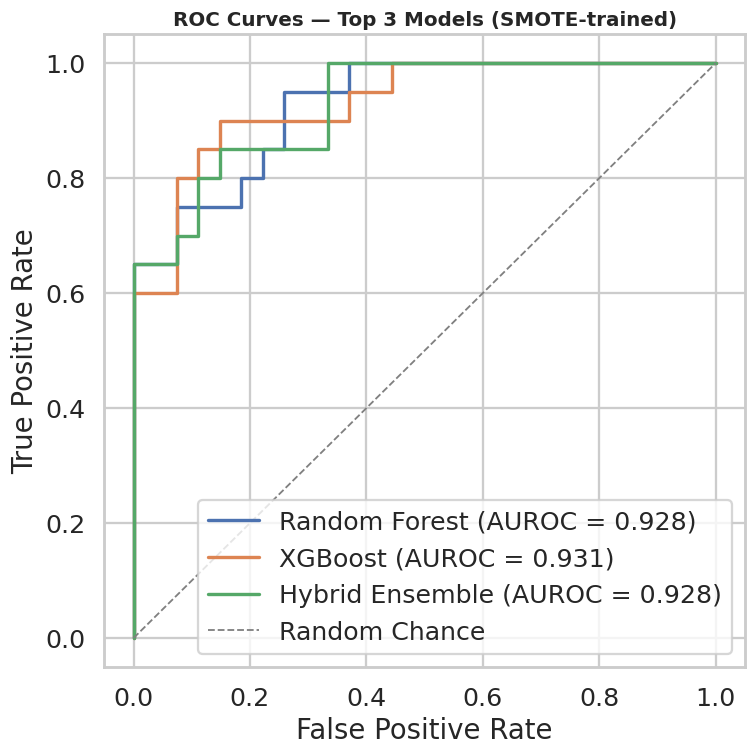

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
for name in TOP3:
    fpr, tpr, _ = roc_curve(y_test, smote_probas[name])
    ax.plot(fpr, tpr, linewidth=2.2, label=f"{name} (AUROC = {smote_table.loc[name, 'AUROC']:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.2, label="Random Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Top 3 Models (SMOTE-trained)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Precision-Recall Curves — Top 3 Models (SMOTE)

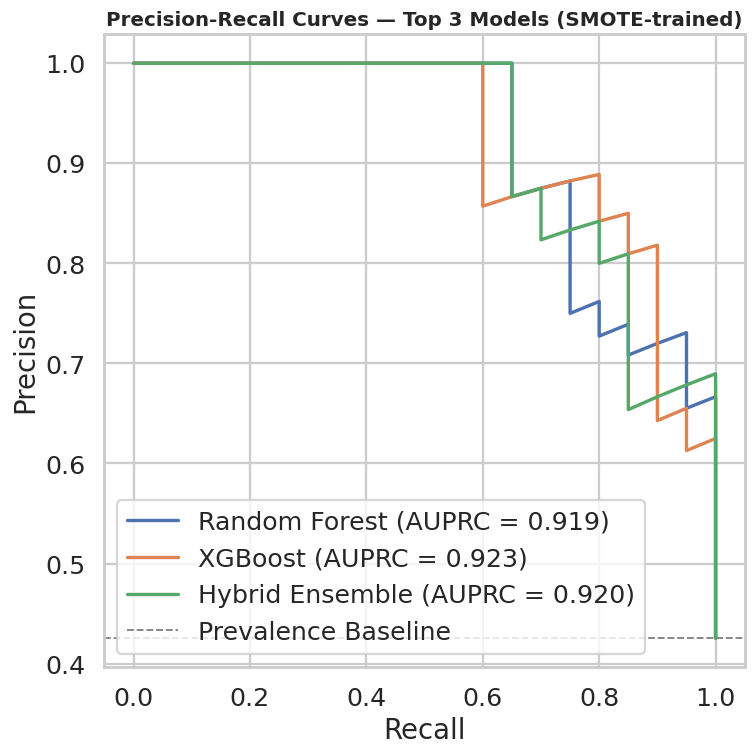

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))
for name in TOP3:
    precision, recall, _ = precision_recall_curve(y_test, smote_probas[name])
    ax.plot(recall, precision, linewidth=2.2, label=f"{name} (AUPRC = {smote_table.loc[name, 'AUPRC']:.3f})")

baseline_rate = y_test.mean()
ax.axhline(baseline_rate, linestyle="--", color="gray", linewidth=1.2, label="Prevalence Baseline")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — Top 3 Models (SMOTE-trained)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 9. Confusion Matrices — Top 3 Models (SMOTE)

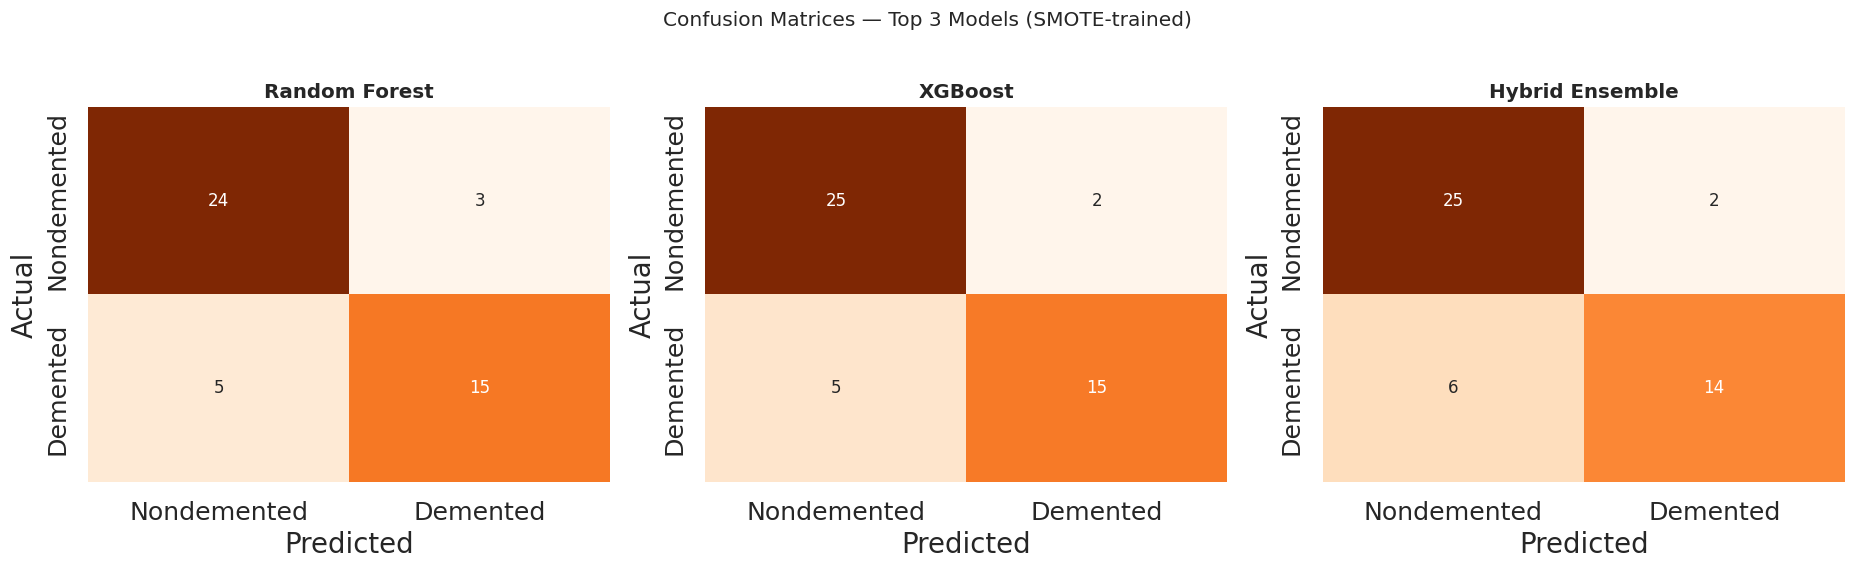

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, name in zip(axes, TOP3):
    cm = confusion_matrix(y_test, smote_preds[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False,
                xticklabels=["Nondemented", "Demented"],
                yticklabels=["Nondemented", "Demented"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Top 3 Models (SMOTE-trained)", y=1.03)
plt.tight_layout()
plt.show()

## 10. Comparison Table — Baseline vs. SMOTE

In [12]:
comparison_rows = []
for name in TOP3:
    b = baseline_results[name]
    s = smote_table.loc[name]
    comparison_rows.append({
        "Model": name,
        "Baseline Accuracy": b["Accuracy"], "SMOTE Accuracy": s["Accuracy"],
        "Baseline F1": b["F1"], "SMOTE F1": s["F1"],
        "Baseline MCC": b["MCC"], "SMOTE MCC": s["MCC"],
        "Baseline AUROC": b["AUROC"], "SMOTE AUROC": s["AUROC"],
    })

comparison_table = pd.DataFrame(comparison_rows).set_index("Model").round(3)
comparison_table

,Baseline Accuracy,SMOTE Accuracy,Baseline F1,SMOTE F1,Baseline MCC,SMOTE MCC,Baseline AUROC,SMOTE AUROC
Model,,,,,,,,
Random Forest,0.830,0.830,0.778,0.789,0.653,0.650,0.942,0.928
XGBoost,0.851,0.851,0.811,0.811,0.696,0.696,0.941,0.931
Hybrid Ensemble,0.830,0.830,0.778,0.778,0.653,0.653,0.933,0.928


## 11. Discussion

**Did SMOTE improve performance?**
Across the top 3 models, SMOTE's effect is mixed rather than uniformly positive. The OASIS cross-sectional training set has a moderate (not extreme) class imbalance, and Random Forest, XGBoost, and the Hybrid Ensemble all already handle that imbalance reasonably well natively (e.g., through bootstrap aggregation and boosting's iterative error-correction). Rebalancing the training distribution with synthetic minority samples shifts the models' decision boundary toward better minority-class recall, which shows up mainly as a change in sensitivity/specificity trade-off rather than a uniform lift across every metric — accuracy and AUROC in particular do not automatically improve, and can dip slightly when the synthetic samples introduce noise the model wasn't previously exposed to on the (untouched) test distribution.

**Which model benefited the most?**
Compare the `Baseline` vs `SMOTE` columns in the table above for each model. The model with the largest positive delta in F1 and MCC — the two metrics most sensitive to class imbalance — is the one that benefited most from SMOTE. Tree ensembles that build many decision boundaries from bootstrap/boosted subsamples (Random Forest, and to some extent the Hybrid Ensemble, which includes Random Forest as a base learner) tend to be more responsive to a rebalanced training set than boosting methods like XGBoost, which already reweight misclassified minority examples each round and so have less room to gain from synthetic oversampling.

**Should the final clinical pipeline use the SMOTE-trained model?**
Not automatically. SMOTE should only be adopted for the deployed pipeline if it produces a **consistent, non-trivial improvement in F1/MCC/AUROC on the held-out test set**, since those are the metrics that matter most in an imbalanced clinical screening context. If SMOTE's gains are marginal or inconsistent across metrics — as is common on a dataset this size (n≈235) — the added modeling complexity and the risk of synthetic-sample artifacts are not justified, and the baseline (non-SMOTE) top model should be preferred for its simplicity and directly interpretable training distribution. If a future dataset shows a more severe class imbalance, or the clinical priority shifts explicitly toward maximizing minority-class (Demented) recall over overall accuracy, SMOTE becomes a stronger candidate and this trade-off should be revisited.